# ¿Que hace a un juego exitoso?

El objetivo del proyecto es identificar patrones que determinen si un juego tiene éxito o no, lo que permitira planificar campañas publicitarias y detectar los proyecyos prometedores.

## 1 Preparando ambiente

-Para este análisis se iniciamos con la limpieza de datos y creación de nuevas carateristicas, con las cuales se realizara una exploración del comportamiento con medidas estadísticas.

In [1]:
# Cargar librerías 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

In [2]:
# carga de datos

df= pd.read_csv('/datasets/games.csv')

In [3]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

## 2 Descripción y limpieza de los datos

Este dataset contiene las siguiente información:

    - Name.- Nombre del videojuego
    - Platform.- Que plataforma lo lanzo (ej. Wii)
    - Year_of_Release.- Año de lanzamiento
    - Genre.- Genero o tipo de videojuego (ej. Sports)
    - NA_sales.- Ventas Nort America
    - EU_sales.- Ventas en European Union
    - JP_sales.- Ventas en Japón
    - Other_sales.- Ventas en el resto del mundo
    - Critic_Score.- Puntaje dado por los criticos (expertos)
    - User_Score.- Puntaje dado por los usuarios
    - Rating.- Clasificación de edad del juego

Realizaremos la exploración de datos, lo cual nos permitirá tener un panorama amplio de la información con la que contamos.

Se realizara una limpieza de datos tomando las siguientes acciones

    - Se cambian los nombres de las columnas a minúscula.
    - Se cambia el tipo de formato de 'user_score' a flot
    

In [4]:
## Obtener una primera visualización de los datos para tener una mejor idea que se necesita para la limpieza de datos

df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
# Imprime la información general/resumida sobre los datos
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


### Corregir datos

In [47]:
## Convertir los titulos de las columnas a minusculas
df.columns = df.columns.str.lower()

## Cambiar 'user_score' a float 
df['user_score_num'] = pd.to_numeric(df['user_score'], errors='coerce')

df['year'] = df['year_of_release'].dropna().astype('int')

In [48]:
## Check de que los cambios se hayan realizado
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,user_score_num,year,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,8.0,2006.0,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,NaN,1985.0,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,8.3,2008.0,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,8.0,2009.0,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,NaN,1996.0,31.38


#### 2.2 Creación de nuevas variables para el análisis

Se agrega la columna 'total_sales' para obtener las ventas totales por juego

In [8]:
# Suma de ventas en todas las regiones
df['total_sales']= df['na_sales']+ df['eu_sales']+ df['jp_sales']+ df['other_sales']

In [9]:
# Check para revisar que los cambios 

df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,user_score_num,year,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,8.0,2006.0,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,NaN,1985.0,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,8.3,2008.0,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,8.0,2009.0,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,NaN,1996.0,31.38


In [10]:
df['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

# 3 Analiza los datos

### Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?


In [11]:

# Preparar conteo por año
games_per_year = df['year'].value_counts().sort_index().rename_axis('year').reset_index(name='n_games')

# Estadísticas descriptivas
games_per_year['n_games'].describe()


count      37.000000
mean      444.486486
std       451.557159
min         9.000000
25%        36.000000
50%       338.000000
75%       762.000000
max      1427.000000
Name: n_games, dtype: float64

In [12]:
games_per_year

,year,n_games
0,1980.0,9
1,1981.0,46
2,1982.0,36
3,1983.0,17
4,1984.0,14
5,1985.0,14
6,1986.0,21
7,1987.0,16
8,1988.0,15
9,1989.0,17


 Tambien notamos que inicialmente, el numero de juegos lanzados era muy pequeño, sin embargo, conforme fue pasando el tiempo y a partir de l994 el numero de juegos se duplico y comenzo a crecer, tomando su auge en el periodo del 2006 al 2011 en donde el numero de lanzamientos eran mas de mil por año.

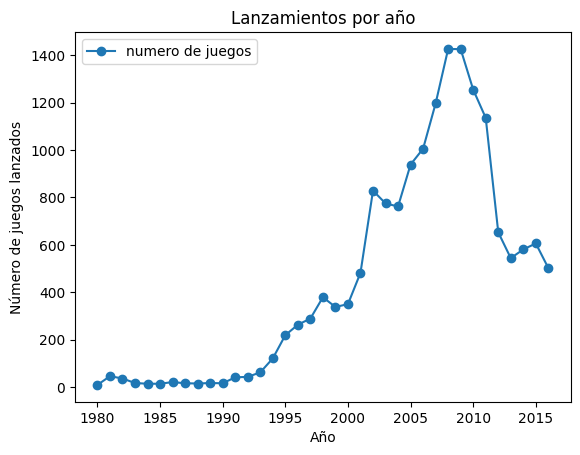

In [13]:
# Visualización: series anual con línea de tendencia y media móvil

plt.plot(games_per_year['year'], games_per_year['n_games'], marker='o', label='numero de juegos')
plt.xlabel('Año')
plt.ylabel('Número de juegos lanzados')
plt.title('Lanzamientos por año')
plt.legend()
plt.show()

In [14]:
### Observamos cómo varían las ventas de una plataforma a otra

In [15]:
#Agrupamos las ventas totales por plataforma, depsues ordenamos de los que tienen 
#mayores ventas a los que tienen menos y finalmente tomamos solo los primeros 10


ventas_por_plataforma = pd.DataFrame(df.groupby(by='platform')['total_sales'].sum().sort_values(ascending=False)).reset_index()
ventas_por_plataforma



,platform,total_sales
0,PS2,1255.77
1,X360,971.42
2,PS3,939.65
3,Wii,907.51
4,DS,806.12
5,PS,730.86
6,GBA,317.85
7,PS4,314.14
8,PSP,294.05
9,PC,259.52


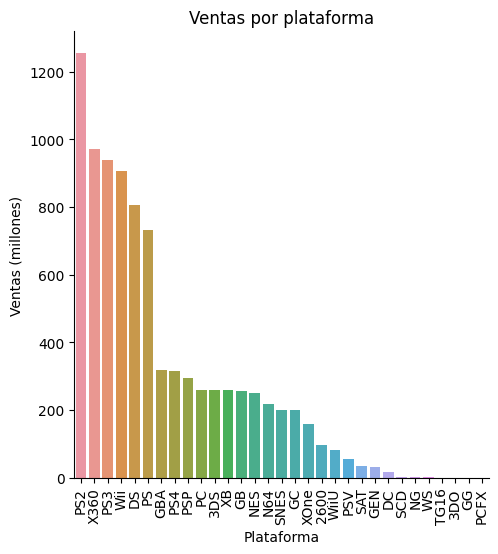

In [16]:

sns.catplot(data=ventas_por_plataforma,x='platform',y='total_sales', kind='bar', )

plt.xticks(rotation=90)
plt.xlabel('Plataforma')
plt.ylabel('Ventas (millones)')
plt.title('Ventas por plataforma')
plt.show()


In [17]:
plataforma_top_ventas=ventas_por_plataforma.head(8)

plataforma_top_ventas

,platform,total_sales
0,PS2,1255.77
1,X360,971.42
2,PS3,939.65
3,Wii,907.51
4,DS,806.12
5,PS,730.86
6,GBA,317.85
7,PS4,314.14


Al tener las 10 empresas con mayores ventas totales volvemos a agrupar pero ahora considerando el año de lanzamiento

In [18]:


top_ventas_plataforma_por_año = pd.DataFrame(df[df['platform'].isin(plataforma_top_ventas['platform'])].groupby(by=['platform','year'])['total_sales'].sum()).reset_index()
top_ventas_plataforma_por_año




,platform,year,total_sales
0,DS,1985.0,0.02
1,DS,2004.0,17.27
2,DS,2005.0,130.14
3,DS,2006.0,119.81
4,DS,2007.0,146.94
...,...,...,...
74,X360,2012.0,99.74
75,X360,2013.0,88.58
76,X360,2014.0,34.74
77,X360,2015.0,11.96


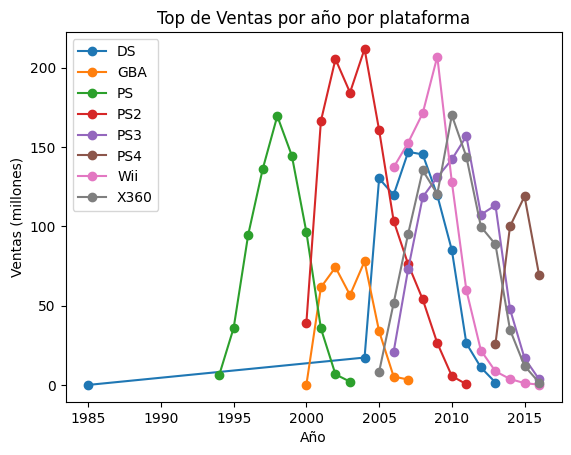

In [19]:

# Distribución de top de plataformas por año


for platform, group in top_ventas_plataforma_por_año.groupby('platform'):
    plt.plot(group['year'], group['total_sales'], marker='o', label=platform)


plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Top de Ventas por año por plataforma')
plt.legend()
plt.show()



Como podemos ver en la figura, las plataformas que solian ser populares pero no han tenido ventas en los ultimos años son:

    - PS
    - GBA
    - PS2
    - DS
    - Wii

¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

Para esta pregunta veremos la diferencia entre el primer juego lanzado y el ultimo por plataforma

In [20]:


top_plataformas_temporalidad=pd.DataFrame(top_ventas_plataforma_por_año.groupby(by='platform').agg({
    'year': ['min','max','count'], 'total_sales': 'sum'})).reset_index()

top_plataformas_temporalidad.columns = ['_'.join(col) for col in top_plataformas_temporalidad.columns]



In [21]:

# Crea la diferencia de años entre el primer juego lanzado y el último
top_plataformas_temporalidad['year_range']=top_plataformas_temporalidad['year_max']-top_plataformas_temporalidad['year_min']


In [22]:
top_plataformas_temporalidad

,platform_,year_min,year_max,year_count,total_sales_sum,year_range
0,DS,1985.0,2013.0,11,802.78,28.0
1,GBA,2000.0,2007.0,8,312.88,7.0
2,PS,1994.0,2003.0,10,727.58,9.0
3,PS2,2000.0,2011.0,12,1233.56,11.0
4,PS3,2006.0,2016.0,11,931.34,10.0
5,PS4,2013.0,2016.0,4,314.14,3.0
6,Wii,2006.0,2016.0,11,891.18,10.0
7,X360,2005.0,2016.0,12,961.24,11.0


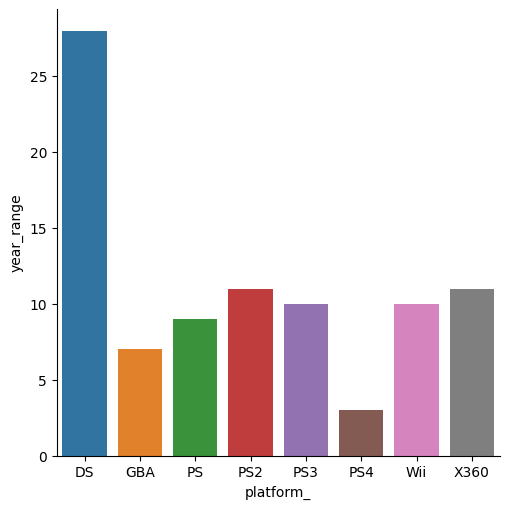

In [23]:


sns.catplot(data=top_plataformas_temporalidad,x='platform_',y='year_range', kind='bar')


plt.show()

In [24]:
top_plataformas_temporalidad.describe()

,year_min,year_max,year_count,total_sales_sum,year_range
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,2001.125000,2012.250000,9.875000,771.837500,11.125000
std,8.592979,4.949747,2.695896,318.879692,7.318031
min,1985.000000,2003.000000,4.000000,312.880000,3.000000
25%,1998.500000,2010.000000,9.500000,624.220000,8.500000
50%,2002.500000,2014.500000,11.000000,846.980000,10.000000
75%,2006.000000,2016.000000,11.250000,938.815000,11.000000
max,2013.000000,2016.000000,12.000000,1233.560000,28.000000


<b>*Observamos que en esta figura se muestra que para la plataforma DS tenemos una extención anomala en el rango de años, lo cual deberá ser revisado*<b>

{'whiskers': [<matplotlib.lines.Line2D at 0x7f57abfbff10>,
 'caps': [<matplotlib.lines.Line2D at 0x7f57ab58fd00>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f57abfbf1f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f57ab58f970>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f57ab58feb0>],
 'means': []}

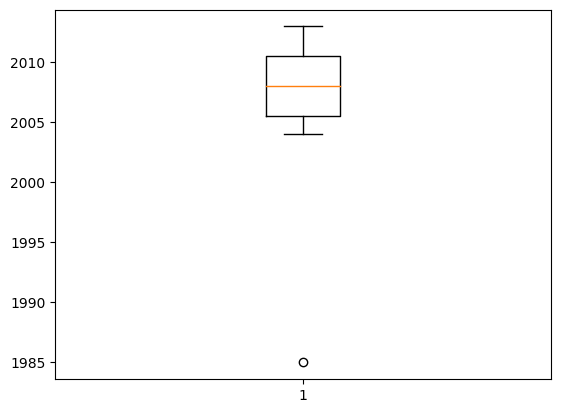

In [25]:
ds_temporalidad= top_ventas_plataforma_por_año[top_ventas_plataforma_por_año['platform']=='DS']['year']
plt.boxplot(ds_temporalidad)

En esta figura observamos el outlier que presenta y genera ese comportamiento anomalo con un valor en el año 1985, por lo que eliminaremos este valor y realizaremos nuevamente las figuras para obtener la temporalidad adecuada

In [26]:

top_ventas_plataforma_por_año[top_ventas_plataforma_por_año['platform']=='DS']
#Si vemos el total de ventas en ese año, esta muy por debajo de los siguientes años,
#por lo que no afecta si lo eliminamos para observar la temporalidad



,platform,year,total_sales
0,DS,1985.0,0.02
1,DS,2004.0,17.27
2,DS,2005.0,130.14
3,DS,2006.0,119.81
4,DS,2007.0,146.94
5,DS,2008.0,145.31
6,DS,2009.0,119.54
7,DS,2010.0,85.02
8,DS,2011.0,26.18
9,DS,2012.0,11.01


In [27]:
top_ventas_plataforma_por_año_limpio=top_ventas_plataforma_por_año.drop(0)

In [28]:
# Volvemos a crear la tabla para encontrar el rango de años
top_plataformas_temporalidad_limpio=pd.DataFrame(top_ventas_plataforma_por_año_limpio.groupby(by='platform').agg({
    'year': ['min','max','count'], 'total_sales': 'sum'})).reset_index()

top_plataformas_temporalidad_limpio.columns = ['_'.join(col) for col in top_plataformas_temporalidad_limpio.columns]

# Crea la diferencia de años entre el primer juego lanzado y el último
top_plataformas_temporalidad_limpio['year_range']=top_plataformas_temporalidad_limpio['year_max']-top_plataformas_temporalidad_limpio['year_min']

top_plataformas_temporalidad_limpio

,platform_,year_min,year_max,year_count,total_sales_sum,year_range
0,DS,2004.0,2013.0,10,802.76,9.0
1,GBA,2000.0,2007.0,8,312.88,7.0
2,PS,1994.0,2003.0,10,727.58,9.0
3,PS2,2000.0,2011.0,12,1233.56,11.0
4,PS3,2006.0,2016.0,11,931.34,10.0
5,PS4,2013.0,2016.0,4,314.14,3.0
6,Wii,2006.0,2016.0,11,891.18,10.0
7,X360,2005.0,2016.0,12,961.24,11.0


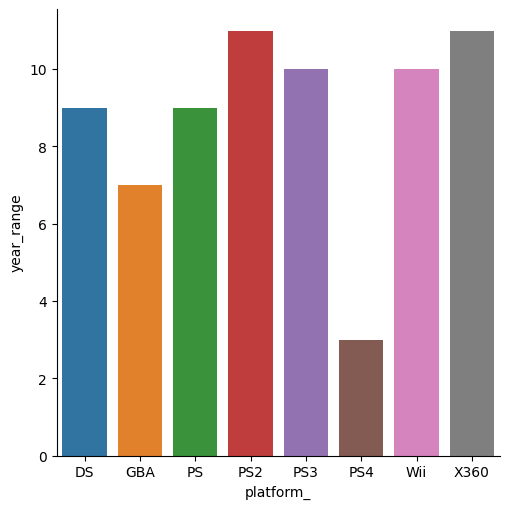

In [29]:
sns.catplot(data=top_plataformas_temporalidad_limpio,x='platform_',y='year_range', kind='bar')


plt.show()

In [30]:
top_plataformas_temporalidad_limpio.describe()

,year_min,year_max,year_count,total_sales_sum,year_range
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,2003.500000,2012.250000,9.750000,771.835000,8.750000
std,5.606119,4.949747,2.659216,318.879415,2.659216
min,1994.000000,2003.000000,4.000000,312.880000,3.000000
25%,2000.000000,2010.000000,9.500000,624.220000,8.500000
50%,2004.500000,2014.500000,10.500000,846.970000,9.500000
75%,2006.000000,2016.000000,11.250000,938.815000,10.250000
max,2013.000000,2016.000000,12.000000,1233.560000,11.000000


#### ¡La plataforma DS tiene un rango de 9 años, una gran diferencia a los 28 que mostraba inicialmente!

En este analisis observamos como las plataformas siguen una tendencia similar, donde inician con pocas ventas pero de pronto tienen un creciminto exponancial, para después caer en ventas. Este comportamiento nos muestra el asenso de diferentes plataformas que pueden entrar en la moda del momento, para después reducir sus ventas hasta casi desaparecer.

En la distribución de las plataformas con las mayores ventas totales observamos observamos clarmente esta tendencia de crecimiento  y caida, en donde encontramos que plataformas que tuvieron gran exito en ventas practicamente desaparecieron con forme sus ventas bajaron, las principales plataformas que ya no tienen ventas son:

    - PS
    - GBA
    - PS2
    - DS
    - Wii

También encontramos que las plataformas tienen una vida media de aproximadamente 8.7 años desde su aparicion hasta su desaparición.



### Periodo significativo para generar publicidad

Como podemos ver por las tendencias que observamos tenemos que tomar datos dentro del periodo de 8 años, sin embargo, para generar una proyeccion para el 2017, ver hacia atras en el tiempo en este periodo, nos encontramos con varias plataformas que ya han desaparecido como pudimos ver en la figura de 'Top de Ventas por año por plataforma', por lo que nos centraremos en los 4 años anteriores, que como podemos ver en la siguiente figura comprenden plataformas activas

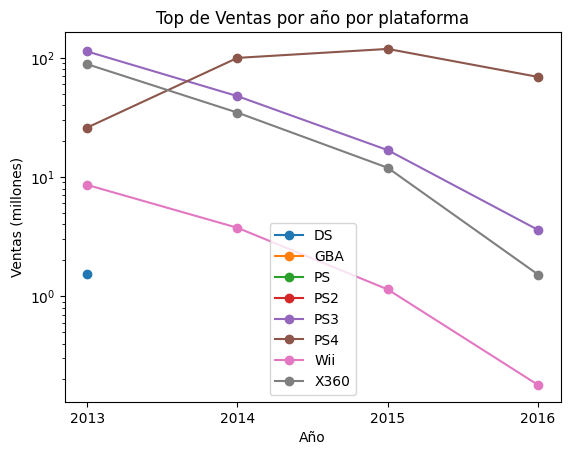

In [32]:

for platform, group in top_ventas_plataforma_por_año.groupby('platform'):
    group=group[group['year']>=2013]
    plt.plot(group['year'], group['total_sales'], marker='o', label=platform)

plt.yscale('log')
plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Top de Ventas por año por plataforma')
plt.locator_params(axis='x', nbins=4, integer=True)
plt.legend()
plt.show()

In [38]:
## Obtenemos todos los datos filtrados para estos 4 años
filtered_df=df[df['year']>=2014]
filtered_df['year'].unique()

array([2015., 2014., 2016.])

In [39]:
ventas_por_plataforma_filt = pd.DataFrame(filtered_df.groupby(by='platform')['total_sales'].sum().sort_values(ascending=False)).reset_index()
ventas_por_plataforma_filt

,platform,total_sales
0,PS4,288.15
1,XOne,140.36
2,3DS,86.68
3,PS3,68.18
4,X360,48.22
5,WiiU,42.98
6,PC,27.05
7,PSV,22.40
8,Wii,5.07
9,PSP,0.36


### ¿Qué plataformas son líderes en ventas?

In [40]:
## Separamos las plataformas con mayores ventas totales y creamos dos dataframes
## 'top_plataforma_analisis' representa a las plataformas con mayores ventas y
## 'low_plataformas_analisis' representa a las de menores ventas

top_plataforma_analisis=ventas_por_plataforma_filt.head(5)
low_plataforma_analisis=ventas_por_plataforma_filt[~ventas_por_plataforma_filt['platform'].isin(top_plataforma_analisis['platform'])].reset_index(drop=True)

In [41]:
top_plataforma_analisis ##Plataformas lideres

,platform,total_sales
0,PS4,288.15
1,XOne,140.36
2,3DS,86.68
3,PS3,68.18
4,X360,48.22


In [42]:
low_plataforma_analisis ## Plataformas menores

,platform,total_sales
0,WiiU,42.98
1,PC,27.05
2,PSV,22.40
3,Wii,5.07
4,PSP,0.36


In [43]:
## Agregamos años de lanzamiento para estos casos en el periodo correspondiente

top_plataforma_por_año_filt = pd.DataFrame(filtered_df[filtered_df['platform'].isin(top_plataforma_analisis['platform'])].groupby(by=['platform','year'])['total_sales'].sum()).reset_index()
low_plataforma_por_año_filt = pd.DataFrame(filtered_df[filtered_df['platform'].isin(low_plataforma_analisis['platform'])].groupby(by=['platform','year'])['total_sales'].sum()).reset_index()

### ¿Cuáles crecen y cuáles se reducen? 

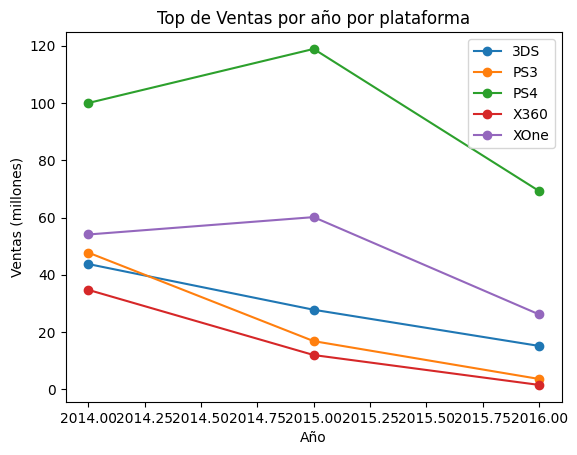

In [44]:
# Distribución plataformas top por año en los ultimos 4 años 


for platform, group in top_plataforma_por_año_filt.groupby('platform'):
    plt.plot(group['year'], group['total_sales'], marker='o', label=platform)


plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Top de Ventas por año por plataforma')
plt.legend()
plt.show()




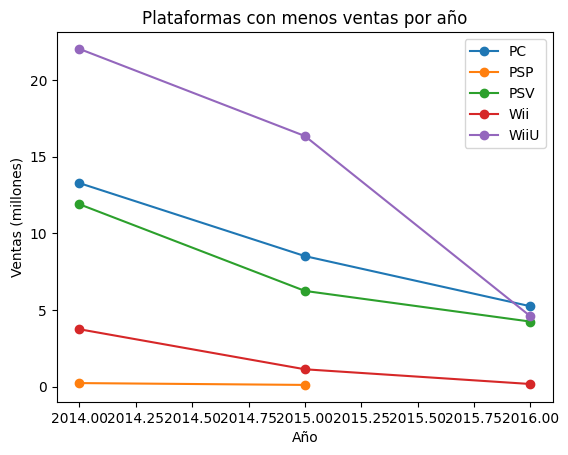

In [49]:

# Distribución plataformas con menores ventas por año en los ultimos 4 años 



for platform, group in low_plataforma_por_año_filt.groupby('platform'):
    plt.plot(group['year'], group['total_sales'], marker='o', label=platform)



plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Plataformas con menos ventas por año')
plt.legend()
plt.show()



A partir de las figuras observamos que existen varias plataformas que ya no tienen ventas en los últimos años, por lo inicialmente descartaremos a estas.

- Las plataformas en crecimiento tenemos dos plataformas que tienen potencial de crecimiento mas notorio que las demas:
  - PS4
  - XOne
  - 3DS

- Las plataformas que se reducen son:

  - PS3
  - X360
  - PC
  - WiiU
  - PSV
  - Wii

- Mientras PSP deja de tener ventas en el 2015.


#### Eligiendo varias plataformas potencialmente rentables.

En las figuras nos damos cuenta como, aún que todas las empresas que se encuentran activas en este periódo tienen un declive en ventas esto puede estar relacionado con la disminución en lanzamientos, por lo que tomaremos 5 empresas que tengan ventas mayores a 0 en 2016

In [50]:
ventas_por_plataforma_filt1=filtered_df[filtered_df['platform'].isin(ventas_por_plataforma_filt['platform'])].reset_index(drop=True)


In [51]:
# Seleccionando las empresas más rentables
empresas_select=ventas_por_plataforma_filt1[ventas_por_plataforma_filt1['year']==2016]['platform'].unique()

In [52]:
empresas_select

array(['PS4', '3DS', 'XOne', 'WiiU', 'PS3', 'PC', 'X360', 'PSV', 'Wii'],
      dtype=object)

In [53]:
empresas_selected=ventas_por_plataforma_filt1[ventas_por_plataforma_filt1['platform'].isin(empresas_select)].reset_index(drop=True)

In [54]:
data=pd.DataFrame(empresas_selected.groupby(by=['platform','year'])['total_sales'].sum()).reset_index()


<Figure size 1400x600 with 0 Axes>

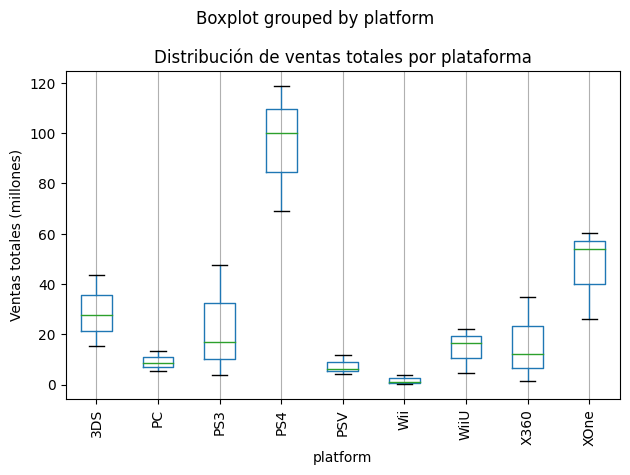

In [55]:
plt.figure(figsize=(14,6))
data.boxplot(column='total_sales', by='platform')
plt.xticks(rotation=90)
plt.ylabel('Ventas totales (millones)')
plt.title('Distribución de ventas totales por plataforma')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

 ¿Son significativas las diferencias en las ventas?

 Observamos diferencuas significativas de plataforma a plataforma, en las cuales vemos como especificamente las plataformas 'PC', 'PSV' y 'WiiU' tienen los margenes mas pequeños en ventas.

Mientras que, al observar las ventas promedio notamos en las plataformas 'PC', 'PSV' y 'WiiU' se encuentran desplazadas hacia abajo, lo que nos dice que el promedio de sus ventas se encuentran por debajo de la mediana.

¿Como afectan las reseñas a las ventas?

En este caso tomaremos como ejemplo 2 empresas prometedoras:
    -PS4
    -3DS
    

In [56]:
platform_ps4 = (empresas_selected[empresas_selected['platform']=='PS4']).reset_index(drop=True)

In [57]:

corr_ps4_critic = platform_ps4[['critic_score','total_sales']].dropna()
corr_ps4_user = platform_ps4[['total_sales','user_score_num']].dropna()


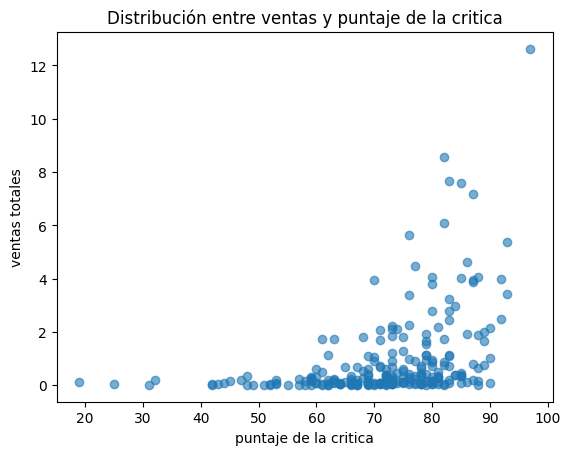

In [58]:

plt.scatter(corr_ps4_critic['critic_score'], corr_ps4_critic['total_sales'], alpha=0.6)
plt.xlabel('puntaje de la critica')
plt.ylabel('ventas totales')
plt.title('Distribución entre ventas y puntaje de la critica')
plt.show()




In [59]:
r,p = st.pearsonr(corr_ps4_critic['critic_score'], corr_ps4_critic['total_sales'])

print(f'La correlación entre el puntaje de la critica y las ventas totales  tiene los siguientes parametros r=',r,' p=',p)


La correlación entre el puntaje de la critica y las ventas totales  tiene los siguientes parametros r= 0.4026614106810408  p= 1.18816150236735e-10


Recordando que la correlación de Pearson es una correlación lineal, notamos que, ya que el valor de r es un número positivo tenemos que a medida que se tiene mejor puntaje en la critica se generan mas ventas, sin embargo al tener un valor aproximado de 0.4 se tiene que esta correlación es moderada, por lo que si podemos establecer una tendencia a este aumento, mientras que el p es muy pequeño, lo que nos dice que si existe una correlacion en la población.

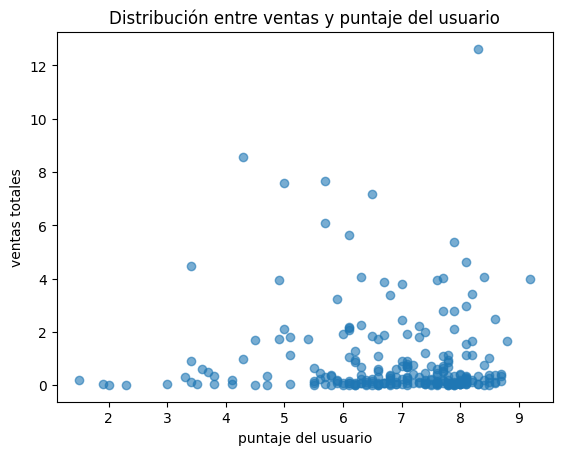

In [60]:
plt.scatter(corr_ps4_user['user_score_num'], corr_ps4_user['total_sales'], alpha=0.6)
plt.xlabel('puntaje del usuario')
plt.ylabel('ventas totales')
plt.title('Distribución entre ventas y puntaje del usuario')
plt.show()

In [61]:


r,p = st.pearsonr(corr_ps4_user['user_score_num'], corr_ps4_user['total_sales'])
print(f'La correlación entre el puntaje de los usuarios y las ventas totales  tiene los siguientes parametros r=',r,' p=',p)



La correlación entre el puntaje de los usuarios y las ventas totales  tiene los siguientes parametros r= -0.04013158947269733  p= 0.5343897553931592


Teniendo en cuenta los parámetros notamos que la p=0.6 es mucho mas grande que el un valor umbral de 0.05, lo que nos dice que no podemos decir que se tiene correlación, también observamos que el valor de r es un valor muy pequeño lo que nos lleva a la misma conclución.

### conculsiones

Se concluye que el puntaje de la crítica tiene una influencia positiva y significativa sobre las ventas, sin embargo, el puntaje de los usuarios no muestra una correlación directa.

¿Como se comportan las ventas de los juegos con otras plataformas?

In [62]:
## para plataformas como ps3, x360 que tienen ventas altas

## En esta sección obtendremos los nombres de los juegos que se manejan en la plataforma 'PS4' y 
# lo filtraaremos con la base de datos que contiene todos los juegos a partir del 2006, para obtener 
# los juegos en el rango de tiempo seleccionado para cada plataforma.


list_of_games_ps4=platform_ps4['name'].unique() 


games=filtered_df[filtered_df['name'].isin(list_of_games_ps4)]

platform_ps3 = (games[games['platform']=='PS3']).reset_index(drop=True)
platform_X360 = (games[games['platform']=='X360']).reset_index(drop=True)


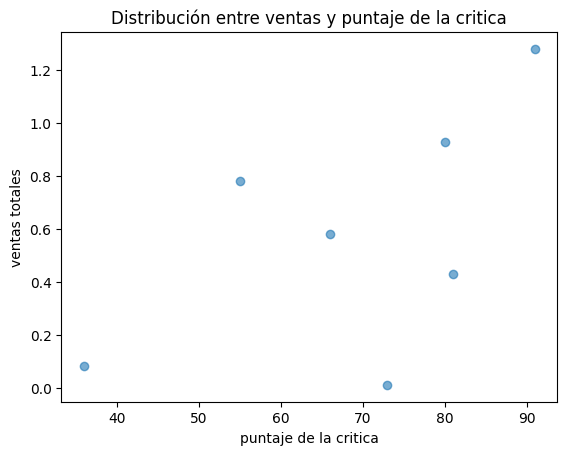

In [63]:

corr_ps3_critic = platform_ps3[['critic_score','total_sales']].dropna()

plt.scatter(corr_ps3_critic['critic_score'], corr_ps3_critic['total_sales'], alpha=0.6)
plt.xlabel('puntaje de la critica')
plt.ylabel('ventas totales')
plt.title('Distribución entre ventas y puntaje de la critica')
plt.show()



In [64]:

r,p = st.pearsonr(corr_ps3_critic ['critic_score'], corr_ps3_critic ['total_sales'])
print(f'La correlación entre el puntaje de los usuarios y las ventas totales  tiene los siguientes parametros r=',r,' p=',p)

La correlación entre el puntaje de los usuarios y las ventas totales  tiene los siguientes parametros r= 0.5692235334930033  p= 0.18227670179954267


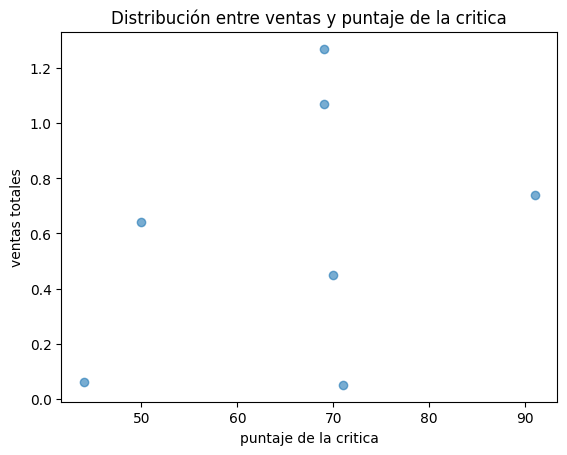

In [65]:
corr_x360= platform_X360[['critic_score','total_sales']].dropna()

plt.scatter(corr_x360['critic_score'], corr_x360['total_sales'], alpha=0.6)
plt.xlabel('puntaje de la critica')
plt.ylabel('ventas totales')
plt.title('Distribución entre ventas y puntaje de la critica')
plt.show()



In [66]:
r,p = st.pearsonr(corr_x360['critic_score'], corr_x360['total_sales'])
print(f'La correlación entre el puntaje de los usuarios y las ventas totales  tiene los siguientes parametros r=',r,' p=',p)

La correlación entre el puntaje de los usuarios y las ventas totales  tiene los siguientes parametros r= 0.34287108173521025  p= 0.45152647911558635


Tomando en cuenta los resultados podemos decir que existe una correlación directa entre el puntaje de la critica y las ventas totales, incluso para plataformasdiferentes para los juegos que encontramos en la 'PS4'

In [75]:
##Primero seleccionamos los juegos

jegos_ventas=empresas_selected.groupby('name')['total_sales'].sum().sort_values(ascending=False)
jegos_ventas

name
Call of Duty: Black Ops 3                            25.67
Call of Duty: Advanced Warfare                       21.97
Grand Theft Auto V                                   19.26
FIFA 15                                              17.37
FIFA 16                                              16.30
                                                     ...  
Naruto Shippuden: Ultimate Ninja Storm Collection     0.01
The Longest 5 Minutes                                 0.01
Farming Simulator 15 Expansion Pack                   0.01
Farming 2017 - The Simulation                         0.01
Fate/kaleid liner Prisma Illya                        0.01
Name: total_sales, Length: 947, dtype: float64

In [84]:
##Seleccionaremos los primeros 5 de esta lista
juegos_seleccionados_ventas=jegos_ventas.head(5)
juegos_seleccionados=juegos_seleccionados_ventas.index.tolist()
juegos_seleccionados

['Call of Duty: Black Ops 3',
 'Call of Duty: Advanced Warfare',
 'Grand Theft Auto V',
 'FIFA 15',
 'FIFA 16']

In [85]:
## Filtramos los datos de estos juegos
juegos_selected=empresas_selected[empresas_selected['name'].isin(juegos_seleccionados)]

In [87]:
juegos_plataformas = pd.pivot_table(juegos_selected, values='total_sales', index='name',columns=['platform'], aggfunc='sum')
juegos_plataformas

platform,3DS,PC,PS3,PS4,PSV,Wii,X360,XOne
name,,,,,,,,
Call of Duty: Advanced Warfare,NaN,0.41,4.36,7.66,NaN,NaN,4.28,5.26
Call of Duty: Black Ops 3,NaN,0.26,1.69,14.63,NaN,NaN,1.70,7.39
FIFA 15,0.46,0.29,4.28,6.08,0.6,0.56,2.92,2.18
FIFA 16,NaN,0.20,2.70,8.58,NaN,NaN,1.57,3.25
Grand Theft Auto V,NaN,1.17,NaN,12.62,NaN,NaN,NaN,5.47


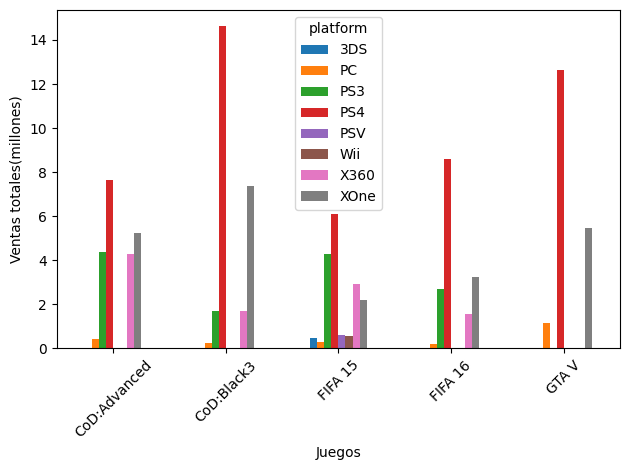

In [94]:
## Ya que los nombres son muy largos y la figura se ve extraña
#, los renombraremos con abreviaturas

juegos_plataformas.plot(kind='bar', rot=45)
custom_labels = ['CoD:Advanced', 'CoD:Black3', 'FIFA 15', 'FIFA 16', 'GTA V']

plt.ylabel('Ventas totales(millones)')
plt.xlabel('Juegos')
posiciones = np.arange(len(custom_labels))
plt.xticks(posiciones,custom_labels, rotation=45)
plt.tight_layout()

plt.show()



Con esto observamos que para los juegos con mayires ventas la mayoría han sido lanzados en 5 plataformas que podemos ver como las principales: 'PC', 'PS3', 'PS4', 'X360' y 'XOne'.

También notamos que la plataforma que lidera las ventas para todos los juegos es 'PS4'.

finalmente notamos que aún que no es el juego con mayores ventas, 'FIFA 15' fue lanzado en todas las plataformas que estamos analizando.

## Distribución general de los juegos por género

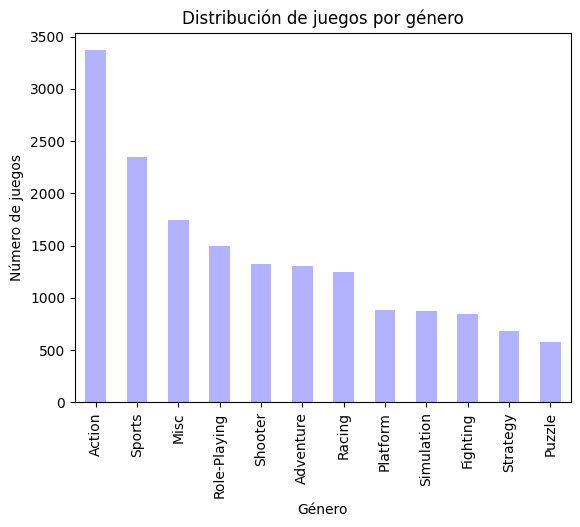

In [49]:
## Contamos cuantos juegos se tienen por género en la base principal

no_games_by_genre = df['genre'].dropna().value_counts()

no_games_by_genre.plot(kind='bar', color='blue', alpha=0.3,xlabel='Género', ylabel='Número de juegos', title='Distribución de juegos por género')

plt.show()



Esta distribución nos muesta que los juegos de 'acción' son los de mayor producción, seguidos de los juegos de 'sports' y 'music', mientras que los juegos 'pizzle' son los de menor producción.

<AxesSubplot:title={'center':'Distribución de ventas por género'}, xlabel='Género', ylabel='Ventas totales'>

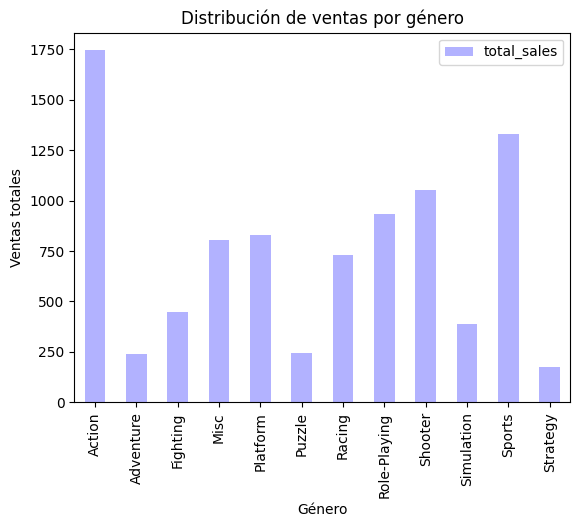

In [50]:
sales_by_genre=df.groupby(by=['genre']).agg(count=('genre', 'size'),total_sales=('total_sales', 'sum')).reset_index()

sales_by_genre.plot(x='genre', y='total_sales', kind='bar', color='blue', alpha=0.3,xlabel='Género', ylabel='Ventas totales', title='Distribución de ventas por género')



Como podemos ver las ventas totales corresponden a los juegos con mas producción tanto en  los juegos de 'acción', como en los juegos  de 'sport', sin embargo, los juegos de 'musica' terminan quedando resagados por otros como 'shooter'.

Respecto a los generos con ventas bajas notamos cooerencia con las ventas y la producción de juegos de géneros como 'Puzzle'

In [51]:

genre_by_year=df.groupby(by=['year','genre']).agg(count=('genre', 'size'),total_sales=('total_sales', 'sum')).reset_index()

genre_by_year.head()


,year,genre,count,total_sales
0,1980.0,Action,1,0.34
1,1980.0,Fighting,1,0.77
2,1980.0,Misc,4,2.70
3,1980.0,Shooter,2,7.07
4,1980.0,Sports,1,0.50


In [52]:
no_games_by_genre_recent = genre_by_year[genre_by_year['year']>2005]
no_games_by_genre_recent

,year,genre,count,total_sales
255,2006.0,Action,184,66.06
256,2006.0,Adventure,71,11.36
257,2006.0,Fighting,55,22.42
258,2006.0,Misc,108,66.97
259,2006.0,Platform,54,49.29
...,...,...,...,...
382,2016.0,Role-Playing,54,18.18
383,2016.0,Shooter,47,38.22
384,2016.0,Simulation,18,1.89
385,2016.0,Sports,48,23.49


In [53]:
genres1=['Action','Sports','Misc','Role-Playing','Shooter','Adventure']
genres2=['Racing', 'Platform', 'Simulation', 'Fighting', 'Strategy', 'Puzzle']

In [54]:

genre1_by_year=no_games_by_genre_recent[no_games_by_genre_recent['genre'].isin(genres1)]
genre2_by_year=no_games_by_genre_recent[no_games_by_genre_recent['genre'].isin(genres2)]

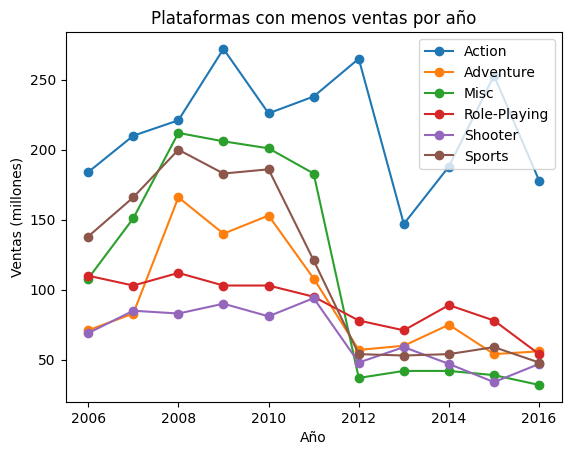

In [55]:
# Distribución plataformas con menores ventas por año en los ultimos 11 años 

for platform, group in genre1_by_year.groupby('genre'):
    plt.plot(group['year'], group['count'], marker='o', label=platform)

plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Plataformas con menos ventas por año')
plt.legend()
plt.show()

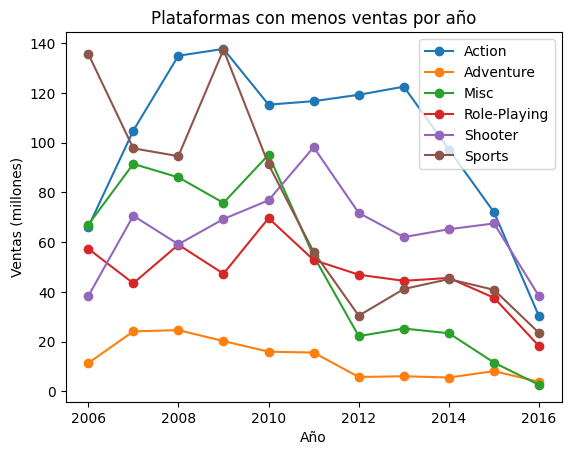

In [56]:
for platform, group in genre1_by_year.groupby('genre'):
    plt.plot(group['year'], group['total_sales'], marker='o', label=platform)



plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Plataformas con menos ventas por año')
plt.legend()
plt.show()

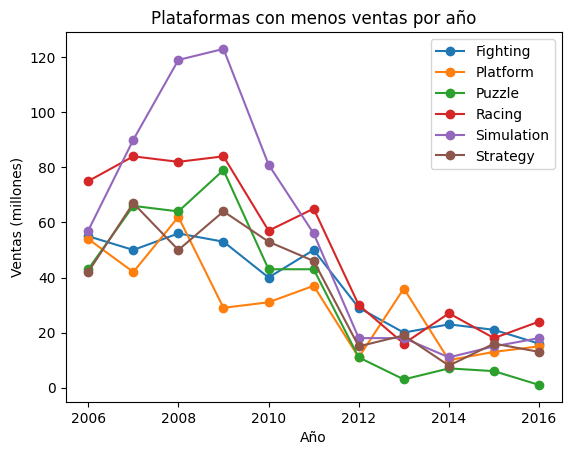

In [57]:


# Distribución plataformas con menores ventas por año en los ultimos 11 años 
for platform, group in genre2_by_year.groupby('genre'):
    plt.plot(group['year'], group['count'], marker='o', label=platform)



plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Plataformas con menos ventas por año')
plt.legend()
plt.show()



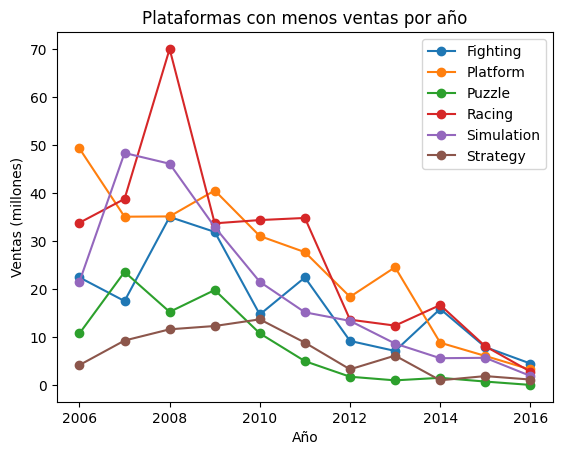

In [58]:

# Distribución plataformas con menores ventas por año en los ultimos 11 años 
for platform, group in genre2_by_year.groupby('genre'):
    plt.plot(group['year'], group['total_sales'], marker='o', label=platform)



plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.title('Plataformas con menos ventas por año')
plt.legend()
plt.show()


# 4 Perfil de usuario para cada región

Inicialmente generaremos una figura del comportamiento de las ventas por región y como se distribuyen en el timepo, despues filtraremos los datos para obtener las plataformas más rentables por cada región.

In [59]:
regions = ['na_sales','eu_sales','jp_sales','other_sales']
sales_year = df.groupby('year')[regions].sum().sort_index()

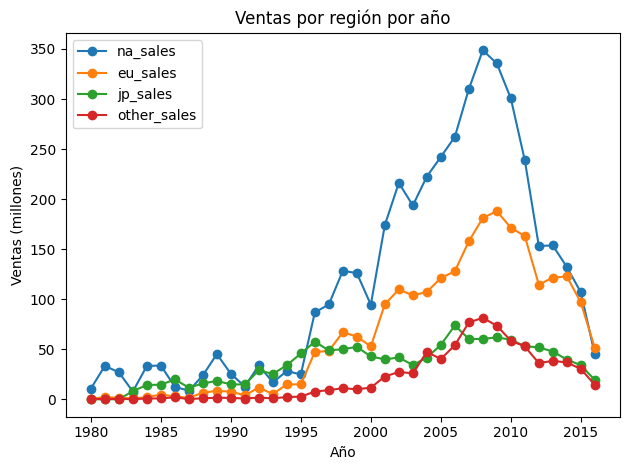

In [60]:
sales_year.plot(marker='o')
plt.ylabel('Ventas (millones)')
plt.xlabel('Año')
plt.title('Ventas por región por año')
plt.tight_layout()
plt.show()

In [61]:
# Obtenemos el total de las ventas por region
region_total = df[regions].sum()
region_total 

na_sales       4402.35
eu_sales       2424.67
jp_sales       1297.37
other_sales     791.32
dtype: float64

# Plataformas principales por región

In [62]:
#Guardaremos un diccionario donde se sumen las ventas por plataforma para cada región,
# ordenando del mayor al menor por ventas y tomando los primeros 5 de la lista, para obtener
# la lista de las 5 plataformas más rentables pr región



top5 = {}
for r in regions: 
    platform_region = df.groupby('platform')[r].sum().sort_index().sort_values(ascending=False).head(5)
    top5[r] = platform_region



In [63]:
# Concateno la información del diccionario para crear una tabla
top5_df = pd.concat(top5, axis=1)

In [64]:

porcent_top_plataformas= top5_df.div(region_total, axis=1) * 100
porcent_top_plataformas


,na_sales,eu_sales,jp_sales,other_sales
platform,,,,
X360,13.685191,11.166880,NaN,10.837588
PS2,13.262008,13.993244,10.729399,24.445231
Wii,11.287153,10.814255,NaN,9.992165
PS3,8.938181,13.622060,NaN,17.146034
DS,8.686270,NaN,13.532762,7.488753
PS,NaN,8.809859,10.777188,NaN
SNES,NaN,NaN,8.983559,NaN
3DS,NaN,NaN,7.759544,NaN


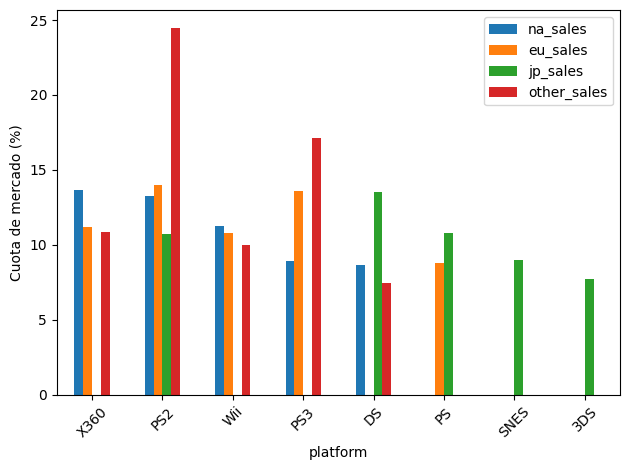

In [65]:

porcent_top_plataformas.plot(kind='bar', rot=45)

plt.ylabel('Cuota de mercado (%)')
plt.tight_layout()
plt.show()



Con esto podemmos notar diferencias claras en las cuotas de mercado, se observa que en Norte America(NA) se tiene una preferencia clara entre las plataformas de X360, PS2, Wii, PS3 y DS, al contrario la región de Japon (JP) se centran en las consolas DS, PS, SNES y 3DS

In [66]:
#Para obtener los generos principales por region

top5_genre = {}
for r in regions: 
    genre_region = df.groupby('genre')[r].sum().sort_index().sort_values(ascending=False).head(5)
    top5_genre[r] = genre_region


In [67]:
# Concateno la información del diccionario para crear una tabla
top5_genre_df = pd.concat(top5_genre, axis=1)

In [68]:
porcent_top_genre= top5_genre_df.div(region_total, axis=1) * 100
porcent_top_genre


,na_sales,eu_sales,jp_sales,other_sales
genre,,,,
Action,19.966836,21.410336,12.442865,23.328110
Sports,15.546924,15.539847,10.447290,16.998180
Shooter,13.452815,13.087967,NaN,13.156498
Platform,10.119595,NaN,10.084247,NaN
Misc,9.251195,8.773977,8.333012,9.400748
Racing,NaN,9.754317,NaN,9.616843
Role-Playing,NaN,NaN,27.394652,NaN


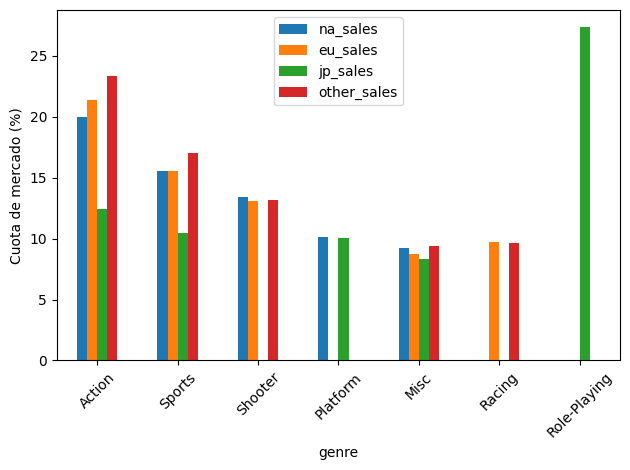

In [69]:


porcent_top_genre.plot(kind='bar', rot=45)
plt.ylabel('Cuota de mercado (%)')
plt.tight_layout()
plt.show()



Las cuotas de mercado muestran diferencias claras por cada región. Mientras que Norteamérica y Europa están dominadas por géneros de acción y competición como Action, Sports y Shooter, Japón presenta una fuerte preferencia por los juegos de rol, que concentran más de una cuarta parte del mercado. Algunos géneros muestran un comportamiento consistente a nivel global como Action, Sports y Music, mientras que otros son altamente dependientes de la región.

In [70]:
#Para obtener como afecta las clasificaciones ESRB por región de forma Global

top5_ESRB = {}
for r in regions: 
    ESRB_region = df.groupby('rating')[r].sum().sort_index().sort_values(ascending=False).head(5)
    top5_ESRB[r] = ESRB_region


In [71]:
top5_ESRB_df = pd.concat(top5_ESRB, axis=1)

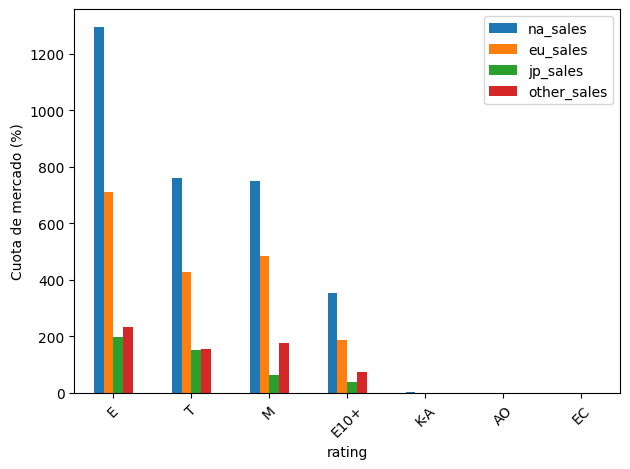

In [72]:

top5_ESRB_df.plot(kind='bar', rot=45)
plt.ylabel('Cuota de mercado (%)')
plt.tight_layout()
plt.show()


#### Clasificaciones por Edades ESRB:

    -EC (Early Childhood - Primera infancia): Apto para niños pequeños (3 años en adelante).
    -E (Everyone - Todos): Apto para todas las edades, incluyendo niños pequeños, con mínima violencia.
    -E10+ (Everyone 10+ - Todos +10): Apto para mayores de 10 años, puede contener más violencia de fantasía.
    -T (Teen - Adolescentes): Apto para adolescentes de 13 años o más, con violencia, lenguaje fuerte o temas sugestivos.
    -M (Mature - Maduro 17+): Contenido apto para mayores de 17 años, incluyendo violencia intensa, sangre, lenguaje fuerte o contenido sexual.
    -AO (Adults Only - Solo Adultos 18+): Contenido de alto nivel, incluyendo violencia gráfica, desnudez o contenido sexual intenso.
    -RP (Rating Pending - Clasificación Pendiente): El juego no ha recibido una calificación definitiva aún. 

Como podemos observar las clasificaciones 'E' aptos para todo publico, 'T' para adolecentes y 'M' para jovenes son los más prolificos, vemos una tendencia muy marcada a buscar videojuegos que sean aptos para todo publico, tambien observamos que las clasificaciones como 'K-A', 'AO' y 'EC' generan poca relevancia comercial

In [73]:
top5_ESRB_df

,na_sales,eu_sales,jp_sales,other_sales
rating,,,,
E,1292.99,710.25,198.11,234.17
T,759.75,427.03,151.40,155.17
M,748.48,483.97,64.24,177.10
E10+,353.32,188.52,40.20,73.56
K-A,2.56,NaN,1.46,NaN
AO,NaN,0.61,NaN,NaN
EC,NaN,NaN,NaN,0.11


## 5. Prueba de hipótesis:

### Hipotesis1:
Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

Para la prueba de hipotesis realizaremos pruebas t.
La hipotesis nula nos dice que no hay diferencia entre el promedio de calificaciones de los usuarios en la plataforma Xbox One y PC. (H0)
Mientras que la alternativa dice que las calificaciones promedio son diferentes. (H1)

Primero probaremos la hipotesis nula

In [108]:
#Obtenemos nuestro conjunto de datos para cada plataforma y eliminiamos las calificaciones que tienen NaN

xbox_one_cali=df[df['platform']=='XOne']['user_score_num'].dropna().reset_index(drop=True)

PC_cali=df[df['platform']=='PC']['user_score_num'].dropna().reset_index(drop=True)



In [109]:


#supongamos a alpha = 0.05
alpha = 0.05

results = st.ttest_ind(
    xbox_one_cali, 
    PC_cali,equal_var=False )

print('valor p: ', results.pvalue)# extrae el valor p de los resultados de la prueba)

if (results.pvalue < alpha):# compara el valor p con el umbral alpha
    print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")



valor p:  4.935072360183574e-06
Rechazamos la hipótesis nula


Con este resultado encontramos que nuestra hipotesis H0 se rechaza al tener un valor muy por debajo de nuestro umbral, por lo que nuestra hipotesis alternativa sería la correcta, SÍ EXISTE UNA DIFERENCIA SIGNIFICATIVA ENTRE LAS CALIFICACIONES EN XBOX Y PC.

### Hipotesis 2:

Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Para esta hipotesis, iniciamos revisando si nuestra hipotesis nula (H0) es rechazada, es decir, revisaremos si las clasificaciones promedio de los usuarios por géneros de acción y deportes son iguales, esperando que nuestra prueba rechaze esta hipotesis, lo que nos diría que la hipotesis alternativa (H1), de que si hay diferencia entre las calificaciones promedio de los usuarios por generos de acción y la de los de deportes es correcta.

In [115]:
#Inicialmente obtenemos nuestros datos, donde neciesitamos los datos de los generos y las calificaciones 
#por usuario
df_gener_calif_user=df[['genre','user_score_num' ]]

accion=df[df['genre']=='Action']['user_score_num'].dropna().reset_index(drop=True)
deporte=df[df['genre']=='Sports']['user_score_num'].dropna().reset_index(drop=True)

In [116]:
#Probemos la hipotesis nula H0

#supongamos a alpha = 0.05
alpha = 0.05

results = st.ttest_ind(
   accion, 
    deporte,equal_var=False )

print('valor p: ', results.pvalue)# extrae el valor p de los resultados de la prueba)

if (results.pvalue < alpha):# compara el valor p con el umbral alpha
    print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")


valor p:  0.11483818791498286
No podemos rechazar la hipótesis nula


Conesto observamos que el valor de p es bastante mayor al valor umbral, lo que nos dice que hay una gran probabilidad de que las variaciones entre el promedio de las calificaciones de los juegos de accion y los de deportes sean debidas a variaciones aleatorias.

con esto no podemos rechazar la hipotesis nula.

## 6 Conclusión general

Finalmente estamos preparados para realizar una conclusión general y contestar ¿Que hace a un juego exitoso?.

    -Nos dimos cuenta como la producción de videojuegos a bajado significativamente en los últimos años, sin embargo se observa un comportamiento peculiar de los juegos lanzados promedio por año por cada plataforma y es que todos al inicio lanzan algunos juegos, hasta que se consolidan teniendo una gran produccion durante aproximadamente 10 años, para despues caer en el numero de lanzamientos y en la mayoria de las ocaciones desaparecer, lo que nos habla de un ciclo de vida de las plataformas.

    -Para las plataformas más exitosas observamos este ciclo también pero se extiende durante más tiempo.

    -Observamos que en los últimos años la preferencia en los generos de los juegos ha ido variando

    -Y dependiendo de la region en la que te encuentres varían los generos más populares

    -Al hacer un analisis por region observamos que estados unidos es el mayor consumidor, por lo que genera grandes ventas promedio, seguido por la union europea.
        -También  observamos que los generos más populares en las regiones occidentales son dirigidos ha generos de acción y competición, mientras que en la región asiatica de japón dominan los juegos de rol.

    Finalmente observamos que en general los juegos más exitosos son aquellos que van dirigidos a una audiencia más amplia, como los clasificados para todas las edades.


### Para mejorar

Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos.
    
Podrías mejorar tus conclusiones incluyendo algunos valores de las métricas más importantes, así las afirmaciones realizadas estarían mejor apoyadas en hechos.
    
